Main notebook for coding and testing.

<header>
    <h1>Install Dependencies</h1>
</header>

In [1]:
# #%pip install --upgrade pip

# %pip install pandas 
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn
# %pip install xlrd
# %pip install scipy
# %pip install statsmodels
# %pip install pandas-datareader
# %pip install fredapi

<header>
    <h2>Import Libraries</h2>
</header>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from fredapi import Fred
import datetime

<header>
    <h2>Import Functions from Source Files</h2>
</header>

In [3]:
from src.CAPM_regression import fit_ols 
from src.visualize import plot_correlation_matrix, plot_regression, plot_returns
from src.sentiment_strategies import calculate_sentiment_signal, calculate_return, multiple_return
from src.compare import compare_strategies

<header>
    <h1>Basic Data Cleaning</h1>
    <bullet>
        <li>Read in sentiment data from AAII</li>
        <li>Get rid of extra data at the bottom of the file (row <= 2020)</li>
        <li>Convert date column to datetime format</li>
        <li>Get rid of useless columns</li>
        <li>Rename columns for ease</li>
        <li>output to .pkl file</li>
    </bullet>
</header>

In [4]:
# sentiment_data = pd.read_excel('data/sentiment_data.xls', header=3)

In [5]:
# cleaned_sentiment_data = sentiment_data[sentiment_data.index <= 2020]

# cleaned_sentiment_data['Date'] = pd.to_datetime(cleaned_sentiment_data['Date'])

# cleaned_sentiment_data = cleaned_sentiment_data[cleaned_sentiment_data['Date'].notna()].drop(columns=['Unnamed: 13'])

# cleaned_sentiment_data = cleaned_sentiment_data.rename(columns={'High':'S&P High', 'Low':'S&P Low', 'Close':'S&P Close'})

# display(cleaned_sentiment_data)

# pd.to_pickle(cleaned_sentiment_data, 'cleaned_sentiment_data.pkl')



<header>
    <h2>More Data Cleaning</h2>
    <bullet>
        <li>Read in .pkl file from previous step</li>
        <li>Get rid of more useless columns</li>
        <li>Ensure datetime format</li>
    </bullet>
</header>

In [6]:
s_df = pd.read_pickle('data/cleaned_sentiment_data.pkl')

s_df.drop(columns = ['Total', 'Average', '+St. Dev.', '- St. Dev.'], inplace = True)

s_df['Date'] = pd.to_datetime(s_df['Date'])

display(s_df)

,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00
...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90


<header>
    <h1>Import Fred Data via API</h1>
    <bullet>
        <li>Use API to import weekly, 6monthrisk free rate data </li>
        <li>
    </bullet>
</header>

In [7]:
fred = Fred(api_key='2156df4aac1a73d06c92ece4a988135f')
start = datetime.datetime(s_df['Date'].iloc[0].year, 1, 1)
end = datetime.datetime.today()

rf_data = (fred.get_series('WTB3MS', start, end)/100)

rf_data = rf_data.reindex(s_df['Date'], method='ffill')

display((rf_data))

Date
1987-06-26    0.0577
1987-07-17    0.0558
1987-07-24    0.0566
1987-07-31    0.0594
1987-08-07    0.0587
               ...  
2026-03-05    0.0360
2026-03-12    0.0360
2026-03-19    0.0361
2026-03-26    0.0362
2026-04-02    0.0363
Length: 2020, dtype: float64

In [8]:
s_df['3-Month Annual T-Bill Rate'] = rf_data.to_numpy()

s_df['3-Month Semi-Annual T-Bill Rate'] = s_df['3-Month Annual T-Bill Rate']/2

s_df['3-Month Monthly T-Bill Rate'] = s_df['3-Month Annual T-Bill Rate'] / 12

s_df['3-Month Weekly T-Bill Rate'] = s_df['3-Month Annual T-Bill Rate'] / 52


display(s_df)


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,3-Month Semi-Annual T-Bill Rate,3-Month Monthly T-Bill Rate,3-Month Weekly T-Bill Rate
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0577,0.02885,0.004808,0.001110
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.0558,0.02790,0.004650,0.001073
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.0566,0.02830,0.004717,0.001088
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.0594,0.02970,0.004950,0.001142
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.0587,0.02935,0.004892,0.001129
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.0360,0.01800,0.003000,0.000692
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.0360,0.01800,0.003000,0.000692
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.0361,0.01805,0.003008,0.000694
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.0362,0.01810,0.003017,0.000696


In [9]:
display(s_df.info())

display(s_df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 1 to 2020
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             2020 non-null   datetime64[us]
 1   Bullish                          2017 non-null   float64       
 2   Neutral                          2017 non-null   float64       
 3   Bearish                          2017 non-null   float64       
 4   Mov Avg                          2003 non-null   float64       
 5   Spread                           2017 non-null   float64       
 6   S&P High                         2019 non-null   float64       
 7   S&P Low                          2019 non-null   float64       
 8   S&P Close                        2019 non-null   float64       
 9   3-Month Annual T-Bill Rate       2020 non-null   float64       
 10  3-Month Semi-Annual T-Bill Rate  2020 non-null   float64       
 11  3-

None

,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,3-Month Semi-Annual T-Bill Rate,3-Month Monthly T-Bill Rate,3-Month Weekly T-Bill Rate
count,2020,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2019.000000,2019.000000,2019.000000,2020.000000,2020.000000,2020.000000,2020.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.375845,0.063077,1776.076360,1729.207499,1756.605254,0.030019,0.015009,0.002502,0.000577
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.175000,-0.540000,233.450000,223.920000,223.920000,-0.000100,-0.000050,-0.000008,-0.000002
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,0.319334,-0.058900,790.305000,764.530000,775.025000,0.003200,0.001600,0.000267,0.000062
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,0.375628,0.070000,1277.630000,1253.120000,1267.430000,0.030250,0.015125,0.002521,0.000582
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,0.428887,0.187310,2151.989990,2099.885000,2132.514966,0.050000,0.025000,0.004167,0.000962
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,0.644650,0.628600,7002.280000,6899.330000,6978.030000,0.090000,0.045000,0.007500,0.001731
std,NaN,0.100208,0.081395,0.098547,0.078673,0.181330,1515.280246,1476.109334,1500.016716,0.024003,0.012002,0.002000,0.000462


From the raw means we can see that Bullish has a mean of 37.%, Neutral has 31.06% and Bearish has 31.31%. This suggests that investors predicted bull more often. 

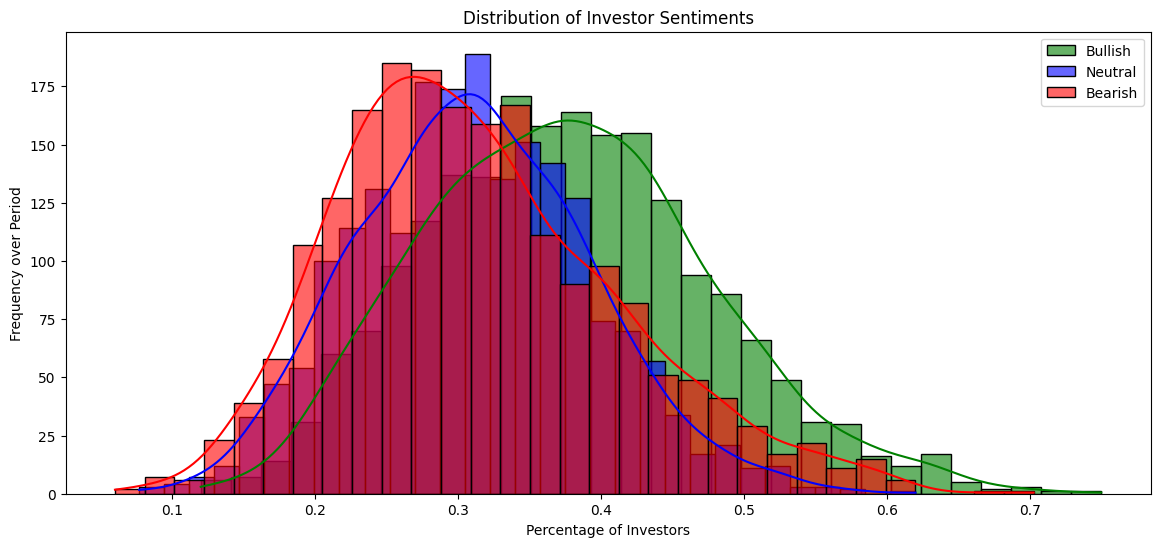

In [10]:
plt.figure(figsize=(14,6))

sns.histplot(s_df['Bullish'], kde=True, color='green', label='Bullish', alpha=0.6)
sns.histplot(s_df['Neutral'], kde=True, color='blue', label='Neutral', alpha=0.6)
sns.histplot(s_df['Bearish'], kde=True, color='red', label='Bearish', alpha=0.6)


plt.title('Distribution of Investor Sentiments')
plt.xlabel('Percentage of Investors')
plt.ylabel('Frequency over Period')
plt.legend()
plt.show()

In [11]:
s_df['Weekly Return'] = (s_df['S&P Close'].shift(-1)/s_df['S&P Close']) - 1 #forward weekly return

s_df['Next 6M Return'] = (s_df['S&P Close'].shift(-26) / s_df['S&P Close']) - 1 #forward monthly return

s_df['Excess Weekly Market Return'] = s_df['Weekly Return'] - s_df['3-Month Weekly T-Bill Rate'] #excess foward weekly returns

s_df['Excess Next 6M Market Return'] = s_df['Next 6M Return'] - s_df['3-Month Semi-Annual T-Bill Rate'] #excess foward 6M returns

display(s_df)

s_df['Market Weekly Return Direction'] = np.sign(s_df['Excess Weekly Market Return'])

s_df['Market Next 6M Return Direction'] = np.sign(s_df['Excess Next 6M Market Return'])

pd.to_pickle(s_df, f'data/{str(datetime.datetime.today())[:10]}_cleaned_sentiment_data.pkl')



display(s_df)

display(s_df.describe())

display(s_df['Next 6M Return'].isna().value_counts())




,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,3-Month Semi-Annual T-Bill Rate,3-Month Monthly T-Bill Rate,3-Month Weekly T-Bill Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0577,0.02885,0.004808,0.001110,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.0558,0.02790,0.004650,0.001073,-0.016911,-0.198798,-0.017984,-0.226698
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.0566,0.02830,0.004717,0.001088,0.030362,-0.202962,0.029273,-0.231262
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.0594,0.02970,0.004950,0.001142,0.013620,-0.193278,0.012477,-0.222978
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.0587,0.02935,0.004892,0.001129,0.034025,-0.223034,0.032896,-0.252384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.0360,0.01800,0.003000,0.000692,-0.013640,NaN,-0.014332,NaN
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.0360,0.01800,0.003000,0.000692,-0.022300,NaN,-0.022992,NaN
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.0361,0.01805,0.003008,0.000694,-0.004951,NaN,-0.005645,NaN
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.0362,0.01810,0.003017,0.000696,-0.002515,NaN,-0.003211,NaN


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,3-Month Semi-Annual T-Bill Rate,3-Month Monthly T-Bill Rate,3-Month Weekly T-Bill Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0577,0.02885,0.004808,0.001110,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.0558,0.02790,0.004650,0.001073,-0.016911,-0.198798,-0.017984,-0.226698,-1.0,-1.0
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.0566,0.02830,0.004717,0.001088,0.030362,-0.202962,0.029273,-0.231262,1.0,-1.0
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.0594,0.02970,0.004950,0.001142,0.013620,-0.193278,0.012477,-0.222978,1.0,-1.0
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.0587,0.02935,0.004892,0.001129,0.034025,-0.223034,0.032896,-0.252384,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.0360,0.01800,0.003000,0.000692,-0.013640,NaN,-0.014332,NaN,-1.0,NaN
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.0360,0.01800,0.003000,0.000692,-0.022300,NaN,-0.022992,NaN,-1.0,NaN
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.0361,0.01805,0.003008,0.000694,-0.004951,NaN,-0.005645,NaN,-1.0,NaN
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.0362,0.01810,0.003017,0.000696,-0.002515,NaN,-0.003211,NaN,-1.0,NaN


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,3-Month Semi-Annual T-Bill Rate,3-Month Monthly T-Bill Rate,3-Month Weekly T-Bill Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction
count,2020,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2019.000000,2019.000000,2019.000000,2020.000000,2020.000000,2020.000000,2020.000000,2018.000000,1993.000000,2018.000000,1993.000000,2018.000000,1993.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.375845,0.063077,1776.076360,1729.207499,1756.605254,0.030019,0.015009,0.002502,0.000577,0.001766,0.048164,0.001189,0.033205,0.135778,0.382840
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.175000,-0.540000,233.450000,223.920000,223.920000,-0.000100,-0.000050,-0.000008,-0.000002,-0.151689,-0.440878,-0.151851,-0.449328,-1.000000,-1.000000
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,0.319334,-0.058900,790.305000,764.530000,775.025000,0.003200,0.001600,0.000267,0.000062,-0.009016,-0.002304,-0.009733,-0.017425,-1.000000,-1.000000
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,0.375628,0.070000,1277.630000,1253.120000,1267.430000,0.030250,0.015125,0.002521,0.000582,0.003456,0.056597,0.002963,0.040807,1.000000,1.000000
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,0.428887,0.187310,2151.989990,2099.885000,2132.514966,0.050000,0.025000,0.004167,0.000962,0.014092,0.111588,0.013569,0.097844,1.000000,1.000000
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,0.644650,0.628600,7002.280000,6899.330000,6978.030000,0.090000,0.045000,0.007500,0.001731,0.113127,0.432530,0.113129,0.431330,1.000000,1.000000
std,NaN,0.100208,0.081395,0.098547,0.078673,0.181330,1515.280246,1476.109334,1500.016716,0.024003,0.012002,0.002000,0.000462,0.022640,0.105338,0.022644,0.105500,0.990985,0.924047


Next 6M Return
False    1993
True       27
Name: count, dtype: int64

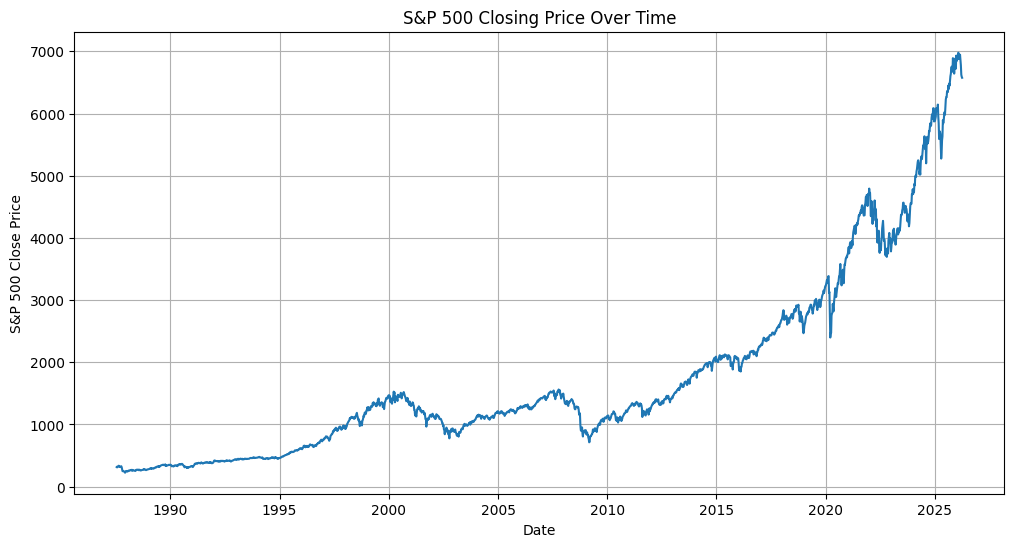

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=s_df, x='Date', y='S&P Close')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Close Price')
plt.grid()



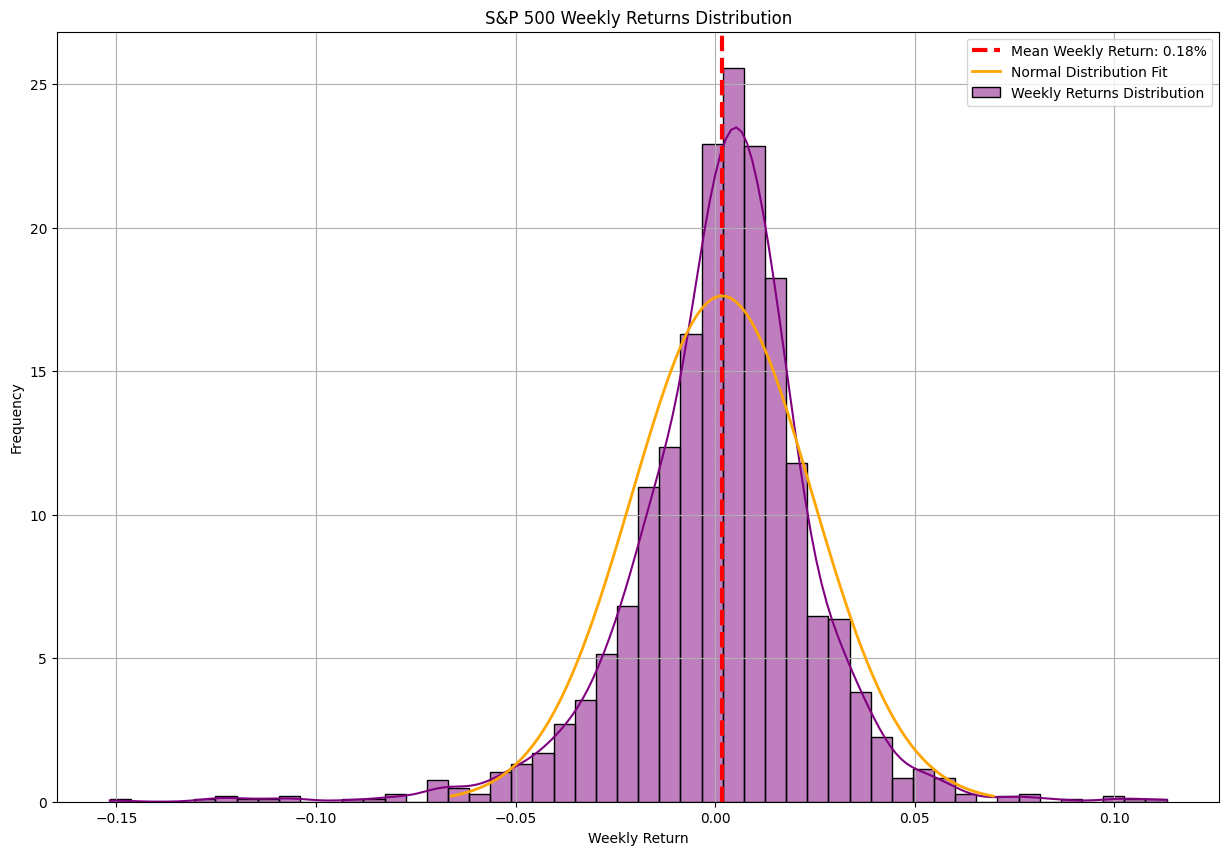

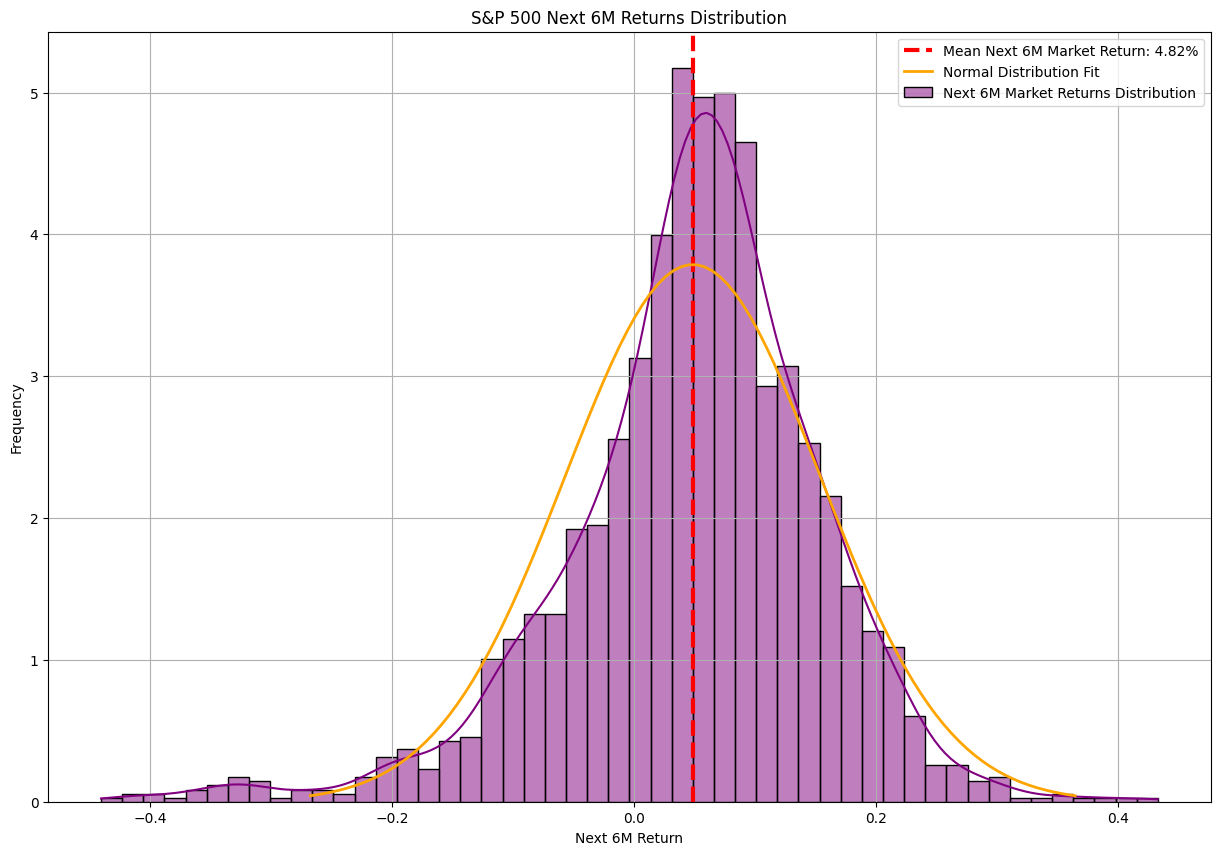

In [13]:
plt.figure(figsize=(15,10))
sns.histplot(data=s_df, x='Weekly Return', bins=50, kde=True, stat='density', color='purple', label='Weekly Returns Distribution')
plt.axvline(s_df['Weekly Return'].mean(), color='red', linestyle='dashed', linewidth=3, label=f'Mean Weekly Return: {s_df["Weekly Return"].mean()*100:.2f}%')

plt.title('S&P 500 Weekly Returns Distribution')
plt.xlabel('Weekly Return')
plt.ylabel('Frequency')

# Source - https://stackoverflow.com/a/10138308
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-19, License - CC BY-SA 4.0

mu = s_df['Weekly Return'].mean()
variance = s_df['Weekly Return'].var()
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

sns.lineplot(x=x, y=stats.norm.pdf(x, mu, sigma), color='orange', linewidth=2, label='Normal Distribution Fit')

plt.legend()

plt.grid()
plt.show()

plt.figure(figsize=(15,10))
sns.histplot(data=s_df, x='Next 6M Return', bins=50, kde=True, stat='density', color='purple', label='Next 6M Market Returns Distribution')
plt.axvline(s_df['Next 6M Return'].mean(), color='red', linestyle='dashed', linewidth=3, label=f'Mean Next 6M Market Return: {s_df["Next 6M Return"].mean()*100:.2f}%')

plt.title('S&P 500 Next 6M Returns Distribution')
plt.xlabel('Next 6M Return')
plt.ylabel('Frequency')

# Source - https://stackoverflow.com/a/10138308
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-19, License - CC BY-SA 4.0

mu = s_df['Next 6M Return'].mean()
variance = s_df['Next 6M Return'].var()
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

sns.lineplot(x=x, y=stats.norm.pdf(x, mu, sigma), color='orange', linewidth=2, label='Normal Distribution Fit')

plt.legend()

plt.grid()
plt.show()

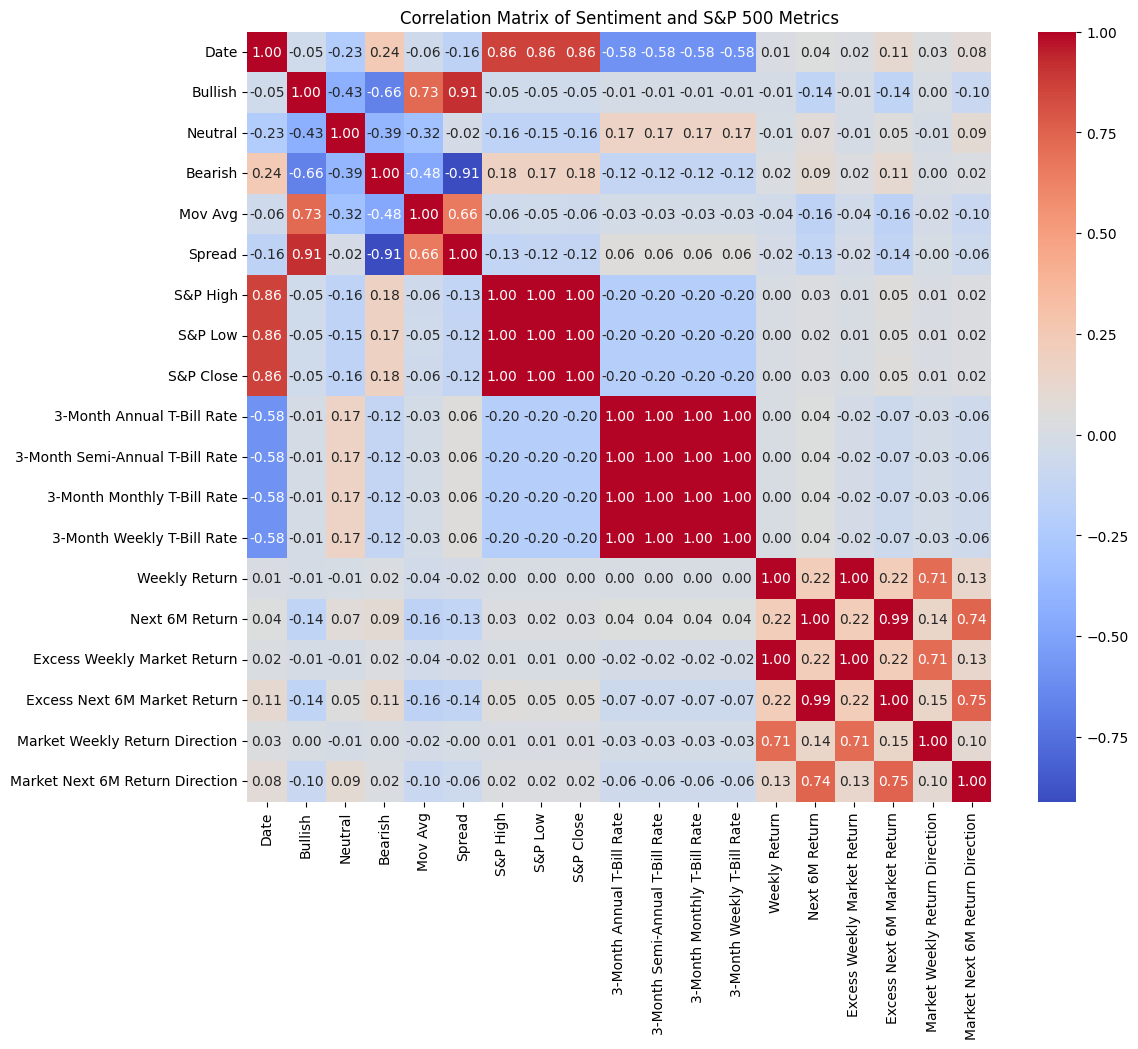

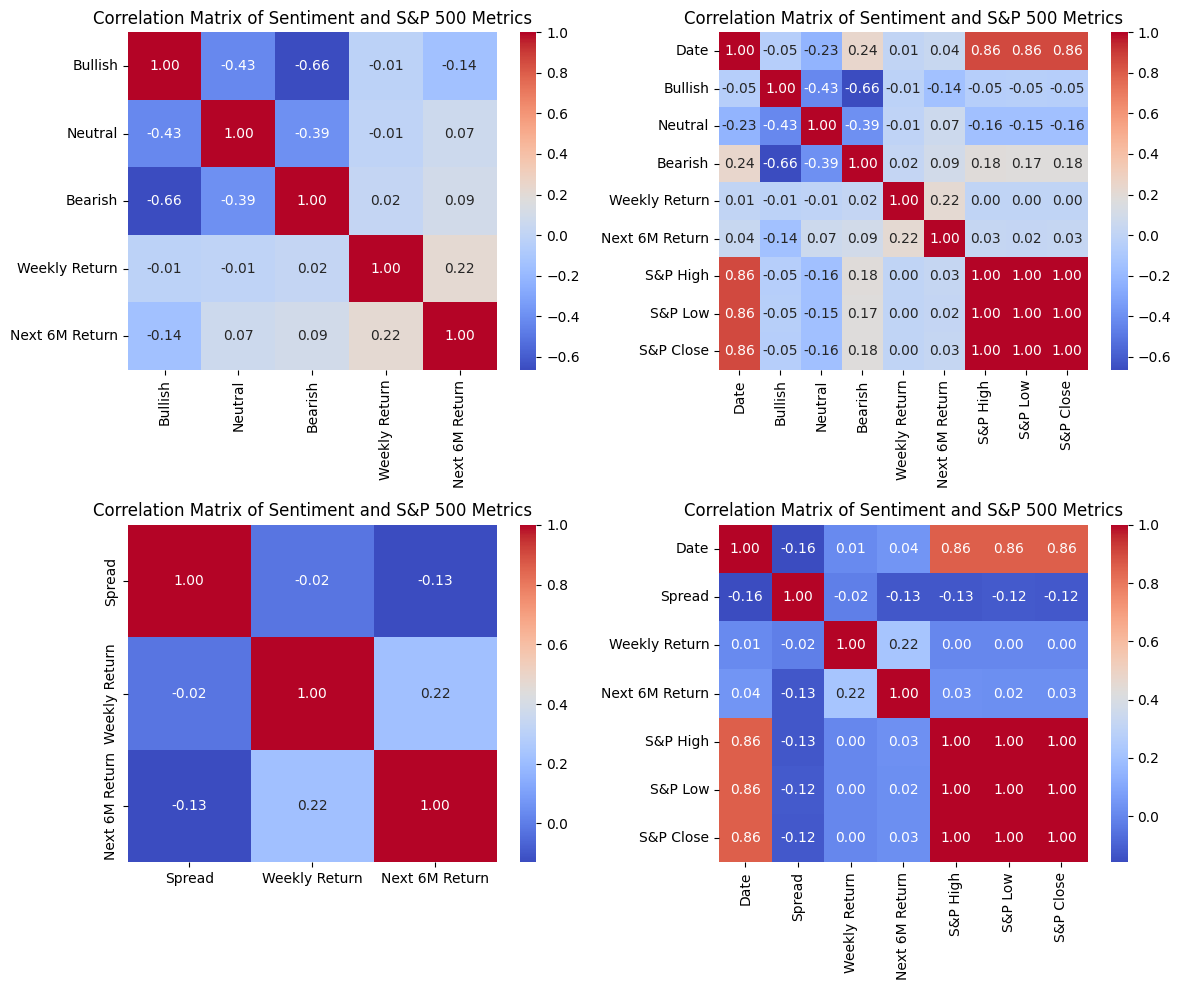

In [14]:
fig, ax = plt.subplots(1,1, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = s_df.columns, ax=ax)

plt.show()


fig, ax = plt.subplots(2,2, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = ['Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return'], ax=ax[0,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[0,1])



plot_correlation_matrix(dataframe = s_df, columns = ['Spread', 'Weekly Return', 'Next 6M Return'], ax=ax[1,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Spread', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[1,1])



plt.tight_layout()
plt.show()




In [15]:
thresholds = pd.Series(np.arange(0,.5 + .025, .025))

signal_sweep = []
for threshold in thresholds:

    signal = str(threshold)[:5] + '_signal'

    signal_sweep.append(signal)

    s_df[signal] = calculate_sentiment_signal(s_df.Spread, threshold=threshold)

display(s_df)


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,3-Month Annual T-Bill Rate,...,0.275_signal,0.300_signal,0.325_signal,0.350_signal,0.375_signal,0.4_signal,0.425_signal,0.45_signal,0.475_signal,0.5_signal
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0577,...,0,0,0,0,0,0,0,0,0,0
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.0558,...,0,0,0,0,0,0,0,0,0,0
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.0566,...,0,0,0,0,0,0,0,0,0,0
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.0594,...,0,0,0,0,0,0,0,0,0,0
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.0587,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.0360,...,0,0,0,0,0,0,0,0,0,0
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.0360,...,0,0,0,0,0,0,0,0,0,0
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.0361,...,0,0,0,0,0,0,0,0,0,0
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.0362,...,0,0,0,0,0,0,0,0,0,0


In [16]:
return_sweep = ['Excess Weekly Market Return']*len(signal_sweep)

dropped_nan_s_df = s_df[~s_df['Excess Weekly Market Return'].isna()]


sweep = multiple_return(dropped_nan_s_df, signal_sweep, return_sweep)

d_s_df = pd.concat([dropped_nan_s_df, sweep], axis=1)

In [17]:
display(compare_strategies(d_s_df, sweep.columns, 'Excess Weekly Market Return').sort_values(by='Sharpe Ratio', ascending=False))


,Strategy,Sharpe Ratio,Beta,Alpha,Cumulative Return
Excess Weekly Market Return,Excess Weekly Market Return,0.052527,1.000496,-5.896978e-07,5.530432
0.300,0.300,0.035119,0.446027,2.643779e-04,1.957652
0.375,0.375,0.034353,0.472938,2.150668e-04,1.857354
0.325,0.325,0.025388,0.357445,1.496601e-04,0.897517
0.350,0.350,0.021220,0.432357,-3.376806e-05,0.568016
0.45,0.45,0.013614,0.809309,-6.542924e-04,0.103318
0.275,0.275,0.013277,0.246991,6.892923e-06,0.092867
0.25,0.25,0.007619,0.168982,-2.833429e-05,-0.156949
0.225,0.225,0.004178,0.187323,-1.281414e-04,-0.280786
0.4,0.4,0.001703,0.620984,-7.000516e-04,-0.359357


In [18]:
import plotly.graph_objects as go

In [19]:
sweep = compare_strategies(d_s_df, sweep.columns, 'Excess Weekly Market Return') 

sns.heatmap(sweep[sweep['Strategy' != 'Excess Weekly Market Return']], x='Strategy', y='Sharpe Ratio', cmap='coolwarm', linewidths=.5)

plt.show()



KeyError: True

In [ ]:
def sharpe_ratio(excess_returns):
    
    return excess_returns.mean() / excess_returns.std()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sharpe_ratios = {}

returns_to_plot = list(sweep.columns) + ['Excess Weekly Market Return']
for r in returns_to_plot:
    plot_returns(d_s_df, r, ax)
    sharpe_ratios[r] = sharpe_ratio(d_s_df[r])

plt.show()

strategy_compare = pd.DataFrame({
    'Strategy': list(sharpe_ratios.keys()),
    'Sharpe Ratio': list(sharpe_ratios.values())
}).sort_values(by='Sharpe Ratio', ascending=False)


display(sharpe_ratios)

In [ ]:
display(sweep)

In [ ]:
signal = calculate_sentiment_signal(s_df.Spread, threshold=.1)

In [ ]:
s_df['Signal'] = signal

In [ ]:
display(s_df[['Date', 'Spread', 'Signal']].head())

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = s_df.columns, ax=ax)

plt.show()


fig, ax = plt.subplots(2,2, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = ['Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return'], ax=ax[0,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[0,1])



plot_correlation_matrix(dataframe = s_df, columns = ['Signal', 'Weekly Return', 'Next 6M Return'], ax=ax[1,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Signal', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[1,1])



plt.tight_layout()
plt.show()


In [ ]:
s_df['Signal'].isna().value_counts()

s_df['Excess Weekly Market Return'].isna().value_counts()

dropped_nan_s_df = s_df[~s_df['Excess Weekly Market Return'].isna()]

In [ ]:
raw_signal_returns = calculate_return(dropped_nan_s_df['Signal'], dropped_nan_s_df['Excess Weekly Market Return'], contrarian=False)

s_df['Raw Signal Strategy Return'] = raw_signal_returns


contrarian_returns = calculate_return(dropped_nan_s_df['Signal'], dropped_nan_s_df['Excess Weekly Market Return'], contrarian=True)

s_df['Contrarian Strategy Return'] = contrarian_returns

display(s_df)

In [ ]:



s_df['Accuracy'] = np.where(s_df['Signal'] == s_df['Market Weekly Return Direction'], 1, 0)

#s_df.drop(s_df['Date'] == 1987-01-01, inplace=True)

In [ ]:
display(s_df.mean())

In [ ]:
s_df['Signal'].value_counts()

In [ ]:
s_df['Risk-Free Rate'] = rf_data.to_numpy()


display(s_df)


In [ ]:
strategy_return = ['Raw Signal Strategy Return', 'Contrarian Strategy Return']

raw_strat_reg = fit_ols(s_df.dropna(), strategy_return[0], 'Excess Weekly Market Return')


contrarian_strat_reg = fit_ols(s_df.dropna(), strategy_return[1], 'Excess Weekly Market Return')

In [ ]:

# display('Strategy Regression Summary: \n', strat_reg.summary())

# display('Long Leg Regression Summary: \n', long_leg_reg.summary())

# display('Short Leg Regression Summary: \n', short_leg_reg.summary())

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

models = [raw_strat_reg, contrarian_strat_reg]

for idx, (model, portfolio) in enumerate(zip(models, strategy_return)):

    plot_regression(s_df, model, portfolio, 'Excess Weekly Market Return', ax=ax[idx])

fig.tight_layout()
plt.show()

In [ ]:
market_return_direction_accuracy = (s_df['Signal'] == s_df['Market Weekly Return Direction']).mean()
print(f'Market Return Direction Accuracy = {market_return_direction_accuracy}')

In [ ]:
sharpe_ratio = s_df['Raw Signal Strategy Return'].mean()/np.sqrt(s_df['Raw Signal Strategy Return'].var())

print(f'Sharpe Ratio = {sharpe_ratio}')

In [ ]:
sharpe_ratio = s_df['Contrarian Strategy Return'].mean()/np.sqrt(s_df['Contrarian Strategy Return'].var())

print(f'Sharpe Ratio = {sharpe_ratio}')

In [ ]:
market_sharpe_ratio = s_df['Excess Weekly Market Return'].mean()/np.sqrt(s_df['Excess Weekly Market Return'].var())
print(f'Market Sharpe Ratio = {market_sharpe_ratio}')

In [ ]:
plt.figure(figsize=(12,6))


cummulative_market_return = (1+ s_df['Excess Weekly Market Return']).cumprod() - 1

sns.lineplot(data=s_df, x='Date', y=cummulative_market_return, label='Market Return')


cummulative_raw_signal_strategy_return = (1+ s_df['Raw Signal Strategy Return']).cumprod() - 1

sns.lineplot(data=s_df, x='Date', y=cummulative_raw_signal_strategy_return, label='Raw Signal Strategy Return')

cummulative_contrarian_strategy_return = (1+ s_df['Contrarian Strategy Return']).cumprod() - 1

sns.lineplot(data=s_df, x='Date', y=cummulative_contrarian_strategy_return, label='Contrarian Strategy Return')


plt.title('Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()
plt.show()


In [ ]:
signal_regression = fit_ols(s_df.dropna(), 'Excess Next 6M Market Return', 'Signal')



In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

plot_regression(s_df, signal_regression, 'Excess Next 6M Market Return', 'Signal', ax)

plt.show()